# 09 — Leakage diagnostics & feature importance

Runs **four leakage checks** from `src.leakage_checks` (embargo, shuffled labels, retrodiction, feature–future correlation) and visualizes **walk-forward permutation importance** from `src.model.permutation_importance_walk_forward` (classification pipeline).

**Data:** same SPI Extra + OHLCV + fundamentals pattern as other training notebooks. Set `TICKER_LIMIT` to a small number for a quick smoke test.

In [4]:
from __future__ import annotations

import logging
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.data_loader import download_ohlcv, load_fundamentals
from src.leakage_checks import print_leakage_report, run_all_leakage_tests
from src.model import permutation_importance_walk_forward
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.figsize"] = (10, 5)

# --- Optional: cap universe for faster runs ---
TICKER_LIMIT = None  # e.g. 40 for a quick test


## Load market data

Uses `config` window and liquidity filter.

In [5]:
from concurrent.futures import ThreadPoolExecutor, as_completed

tickers = get_spi_extra_tickers()
if TICKER_LIMIT is not None:
    tickers = tickers[:TICKER_LIMIT]

ohlcv_by_ticker = download_ohlcv(tickers, start=config.YF_START, end=config.YF_END, cache_dir=config.DATA_DIR)
liquid_tickers = filter_by_min_volume(ohlcv_by_ticker, config.MIN_DAILY_VOLUME_CHF)
ohlcv_by_ticker = {t: ohlcv_by_ticker[t] for t in liquid_tickers if t in ohlcv_by_ticker}

fundamentals_by_ticker: dict[str, dict] = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {pool.submit(load_fundamentals, t, cache_dir=config.DATA_DIR): t for t in ohlcv_by_ticker}
    for fut in as_completed(futs):
        t = futs[fut]
        try:
            fundamentals_by_ticker[t] = fut.result()
        except Exception as exc:
            logging.warning("Fundamentals failed for %s: %s", t, exc)

print(f"Tickers: {len(ohlcv_by_ticker)}, Fundamentals: {len(fundamentals_by_ticker)}")


ERROR yfinance: $ACHI.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['ACHI.SW']: possibly delisted; no timezone found
ERROR yfinance: $AFP.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['AFP.SW']: possibly delisted; no timezone found
ERROR yfinance: $AIRE.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['AIRE.SW']: possibly delisted; no timezone found
ERROR yfinance: $ARON.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['ARON.SW']: possibly delisted; no timezone found
ERROR yfinance: $BALN.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['BALN.SW']: possibly delisted; no timezone found
ERROR yfinance: $BLS.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['BLS.SW']: possibly delisted; no timezone found
ERROR yfinance

Tickers: 141, Fundamentals: 141


## Leakage tests (Pass / Fail table)

Calls `run_all_leakage_tests`. See `src/leakage_checks.py` for thresholds and interpretations.

In [6]:
leakage_results = run_all_leakage_tests(
    ohlcv_by_ticker,
    fundamentals_by_ticker,
    random_seed=config.RANDOM_SEED,
)

summary = pd.DataFrame(
    [
        {
            "test": r.test_name,
            "pass": r.passed,
            "metric": r.metric_name,
            "value": r.metric_value,
            "baseline": r.baseline_value,
        }
        for r in leakage_results
    ]
)
display(summary)
n_pass = sum(1 for r in leakage_results if r.passed)
print(f"\nOverall: {n_pass}/{len(leakage_results)} tests passed")

_ = print_leakage_report(leakage_results)


INFO src.leakage_checks: Leakage diagnostics: running embargo test…
INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 23.9%)
INFO src.features: Dropped 9 correlated features (|rho| > 0.85): ['sma_ratio_50_200', 'macd_diff_norm', 'hvol_60d', 'atr_14_pct', 'spread_proxy', 'dist_52w_high', 'zscore_20d', 'inv_pe_x_mom_6m', 'pe_vs_sector_median']
INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 23.5%)
INFO src.features: Dropped 8 correlated features (|rho| > 0.85): ['macd_diff_norm', 'hvol_60d', 'atr_14_pct', 'bb_width', 'spread_proxy', 'zscore_20d', 'inv_pe_x_mom_6m', 'pe_vs_sector_median']
INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 23.1%)
INFO src.features: Dropped 5 correlated features (|rho| > 0.85): ['sma_ratio_50_200', 'atr_14_pct', 'spread_proxy', 'zscore_20d', 'pe_vs_sector_median']
INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 22.3%)
INFO src.features: Dropped 6 correlated features (|rho

,test,pass,metric,value,baseline
0,embargo,True,IC_drop (standard − embargo),0.000820,0.034354
1,shuffled_labels,True,mean_abs_IC_shuffled,0.034512,-0.017671
2,retrodiction,True,IC_forward − IC_backward,-0.026040,0.023663
3,feature_future_correlation,True,mean_rho_gap (|fwd| − |bwd|),-0.175774,NaN



Overall: 4/4 tests passed
  LEAKAGE DIAGNOSTICS REPORT

--- EMBARGO [✅ PASS] ---
  IC_drop (standard − embargo) = 0.0008
  baseline = 0.0344
  Standard walk-forward IC=0.0344, embargo(1Q) IC=0.0335, delta=0.0008.  PASS — small drop.

--- SHUFFLED_LABELS [✅ PASS] ---
  mean_abs_IC_shuffled = 0.0345
  baseline = -0.0177
  Real IC=-0.0177, shuffled mean|IC|=0.0345 (n=10).  PASS — shuffled IC near zero.

--- RETRODICTION [✅ PASS] ---
  IC_forward − IC_backward = -0.0260
  baseline = 0.0237
  Forward IC=0.0237 (train ≤2019, test ≥2020), backward IC=0.0497, delta=-0.0260.  PASS — forward >= backward.

--- FEATURE_FUTURE_CORRELATION [✅ PASS] ---
  mean_rho_gap (|fwd| − |bwd|) = -0.1758
  Mean |rho_forward|−|rho_backward| = -0.1758 across 43 features.  PASS — no systematic forward bias.

--- Overall: 4/4 passed ---


## Feature importance — walk-forward permutation importance

Trains a Random Forest per OOS year on pre-OOS quarters and reports mean permutation importance on the OOS set (`src.model.permutation_importance_walk_forward`). This matches the **classification** pipeline used in robustness tests.

INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 23.9%)
INFO src.features: Dropped 9 correlated features (|rho| > 0.85): ['sma_ratio_50_200', 'macd_diff_norm', 'hvol_60d', 'atr_14_pct', 'spread_proxy', 'dist_52w_high', 'zscore_20d', 'inv_pe_x_mom_6m', 'pe_vs_sector_median']
INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 23.5%)
INFO src.features: Dropped 8 correlated features (|rho| > 0.85): ['macd_diff_norm', 'hvol_60d', 'atr_14_pct', 'bb_width', 'spread_proxy', 'zscore_20d', 'inv_pe_x_mom_6m', 'pe_vs_sector_median']
INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 23.1%)
INFO src.features: Dropped 5 correlated features (|rho| > 0.85): ['sma_ratio_50_200', 'atr_14_pct', 'spread_proxy', 'zscore_20d', 'pe_vs_sector_median']
INFO src.features: Feature matrix: 141 tickers x 43 features (NaN rate 22.3%)
INFO src.features: Dropped 6 correlated features (|rho| > 0.85): ['sma_ratio_50_200', 'hvol_60d', 'atr_14_pct', 'spread_pr

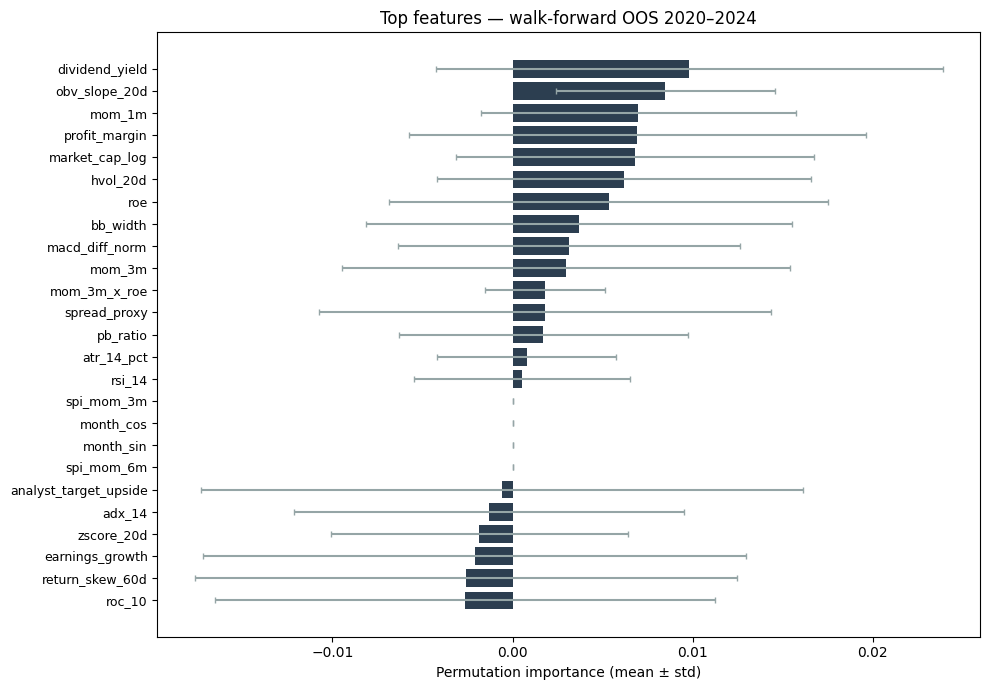

,importance_mean,importance_std,n_years
feature,,,
dividend_yield,0.009800,0.014074,5
obv_slope_20d,0.008480,0.006071,5
mom_1m,0.006989,0.008736,5
profit_margin,0.006919,0.012691,5
market_cap_log,0.006810,0.009944,5
hvol_20d,0.006171,0.010388,5
roe,0.005339,0.012183,5
bb_width,0.003680,0.011835,5
macd_diff_norm,0.003117,0.009491,5


In [7]:
OOS_YEARS = [2020, 2021, 2022, 2023, 2024]

pi_df = permutation_importance_walk_forward(
    ohlcv_by_ticker,
    fundamentals_by_ticker,
    oos_years=OOS_YEARS,
    random_seed=config.RANDOM_SEED,
    n_repeats=5,
)

if pi_df.empty:
    print("No permutation-importance rows (check data coverage and OOS years).")
else:
    top = pi_df.head(25).sort_values("importance_mean")
    fig, ax = plt.subplots(figsize=(10, max(5, len(top) * 0.28)))
    ax.barh(range(len(top)), top["importance_mean"].values, xerr=top["importance_std"].values, color="#2c3e50", ecolor="#95a5a6", capsize=2)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.set_xlabel("Permutation importance (mean ± std)")
    ax.set_title(f"Top features — walk-forward OOS {min(OOS_YEARS)}–{max(OOS_YEARS)}")
    plt.tight_layout()
    plt.show()
    display(pi_df.head(20))
